In [18]:
import pandas as pd
import numpy as np
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.linear_model import LassoCV

In [14]:
def centerData(data):
    mu = np.mean(data,axis=0)
    data = data - mu
    return data, mu

## Data processing

In [15]:
# download orginal dataset
df=pd.read_csv("case1Data.csv")

# create vector for target variable (y)
y_class=df["y"]

# create dataframe for features, numerical and categorical (x)
data=df.drop("y",axis=1)

# only categorical features
categorical_data=data[["C_01", "C_02", "C_03", "C_04", "C_05"]]

# only numeric features
numerical_data=data.drop(columns=categorical_data.columns)

numerical_data = numerical_data.fillna(numerical_data.median(numeric_only=True))
print(numerical_data.isna().sum())

categorical_data.drop(columns="C_02", inplace=True)

categorical_data = categorical_data.fillna("missing")
print(categorical_data.isna().sum())

categorical_data = pd.get_dummies(categorical_data)
categorical_data = categorical_data.astype(int)
categorical_data.head()

categorical_data.columns = categorical_data.columns.str.replace(".0", "", regex=False)
categorical_data.head()

X = pd.concat([numerical_data, categorical_data], axis=1)
print(X.shape)
X.head()

x_01    0
x_02    0
x_03    0
x_04    0
x_05    0
       ..
x_91    0
x_92    0
x_93    0
x_94    0
x_95    0
Length: 95, dtype: int64
C_01    0
C_03    0
C_04    0
C_05    0
dtype: int64
(100, 119)


,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,x_10,...,C_04_73,C_04_74,C_04_75,C_04_missing,C_05_71,C_05_72,C_05_73,C_05_74,C_05_75,C_05_missing
0,6.359019,-13.367120,-2.483750,-6.641891,11.733539,-3.771067,-17.085361,22.194764,16.827888,-10.367142,...,1,0,0,0,0,0,1,0,0,0
1,3.873664,-8.470389,-3.055012,-5.793856,11.420983,1.822330,-13.694100,22.738654,20.307503,-2.859097,...,1,0,0,0,0,0,1,0,0,0
2,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,22.435510,15.963889,-3.257940,...,0,1,0,0,0,0,0,1,0,0
3,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,-5.616061,...,0,0,0,0,0,1,0,0,0,0
4,3.116458,-8.518713,-6.796050,-5.793856,7.646285,-3.118309,-13.102567,22.801217,16.680208,-3.357765,...,0,1,0,0,0,0,0,0,1,0


## 1.1 Nested Cross Validation for RMSE

In [16]:
X_np = X.values
y_np = y_class.values

# numerical columns to standardize
num_cols = numerical_data.columns
num_idx = [X.columns.get_loc(c) for c in num_cols]

# for the repetitions of the outer cv
repetitions_rmse = []

# save hyperparameters from model selection
best_alphas = []
best_ratios = []

# residual analysis
y_cv_true = []
y_cv_pred = []

# save selected features
n_selected_list = []
selection_counts = np.zeros(X.shape[1])

outer_folds = 5
n_repeats = 10

# change composition of folds
for repeat in range(n_repeats):
    outer_cv = KFold(n_splits=outer_folds, shuffle=True, random_state=42 + repeat)  # change seed each repeat
    
    # an error value per outer test fold (5 test folds)
    folds_rmse = []

    # outer cv for model evaluation
    for train_out_idx, test_out_idx in outer_cv.split(X_np):

        X_out_train = X_np[train_out_idx].copy()
        y_out_train = y_np[train_out_idx]
        X_out_test = X_np[test_out_idx].copy()
        y_out_test = y_np[test_out_idx]
        
        #for X: standardize only numerical features
        scaler = StandardScaler()
        X_out_train[:, num_idx] = scaler.fit_transform(X_out_train[:, num_idx])
        X_out_test[:, num_idx] = scaler.transform(X_out_test[:, num_idx])
        #for y: only center
        y_out_train_centered, mu = centerData(y_out_train)
        y_out_test_centered = y_out_test - mu

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            # automatic inner cv for model selection
            l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9,1]  # 1.0 = pure Lasso, 0.0 = Ridge
            # min rmse to get best lambda
            elastic_model = ElasticNetCV(l1_ratio=l1_ratios,alphas=None,cv=5,fit_intercept=False,max_iter=10000,n_jobs=-1)
            elastic_model.fit(X_out_train, y_out_train_centered)

        best_alpha = elastic_model.alpha_
        best_alphas.append(best_alpha)

        best_ratio = elastic_model.l1_ratio_
        best_ratios.append(best_ratio)

        # number of selected features
        coef_best = elastic_model.coef_
        selected = (coef_best != 0)
        n_selected_list.append(selected.sum())
        selection_counts += selected

        # evaluation on outer test set
        y_out_pred = X_out_test @ coef_best
        rmse_fold = np.sqrt(np.mean((y_out_pred - y_out_test_centered)**2))
        folds_rmse.append(rmse_fold)
        
        y_cv_true.extend(y_out_test_centered) 
        y_cv_pred.extend(y_out_pred)

    repetitions_rmse.extend(folds_rmse)

nested_cv_rmse = np.mean(repetitions_rmse)
nested_cv_std = np.std(repetitions_rmse) / np.sqrt(len(repetitions_rmse))
print(f"Repeated Nested CV estimated RMSE: {nested_cv_rmse:.4f} ± {nested_cv_std:.4f}")

print(f"Mean best_alpha: {np.mean(best_alphas):.4f}")
print(f"Std of best_alpha: {np.std(best_alphas):.4f}")

overall_std = np.std(repetitions_rmse)
print(f"Overall std: {overall_std:.4f}")

c:\Users\Maria\anaconda3\envs\compdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(
c:\Users\Maria\anaconda3\envs\compdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(
c:\Users\Maria\anaconda3\envs\compdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(
c:\Users\Maria\anaconda3\envs\compdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=

Repeated Nested CV estimated RMSE: 33.9959 ± 0.5739
Mean best_alpha: 2.0318
Std of best_alpha: 1.5357
Overall std: 4.0583


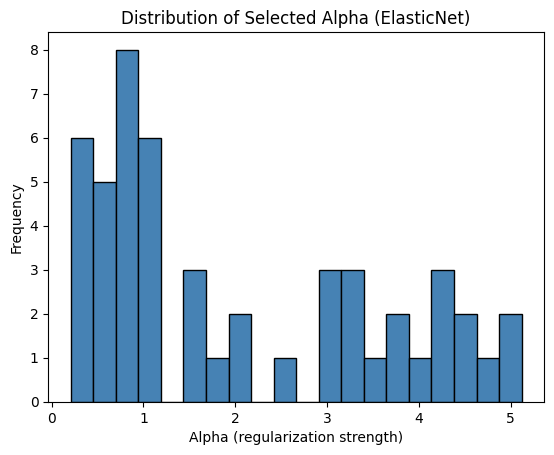

In [6]:
plt.figure()
plt.hist(best_alphas, bins=20, color='steelblue', edgecolor='black')
plt.xlabel("Alpha (regularization strength)")
plt.ylabel("Frequency")
plt.title("Distribution of Selected Alpha (ElasticNet)")
plt.show()

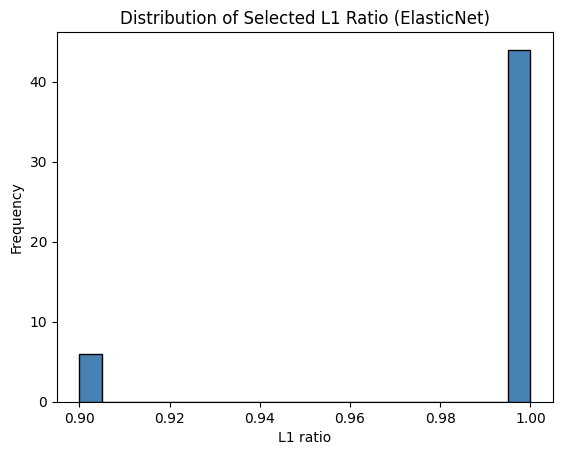

In [8]:
plt.figure()
plt.hist(best_ratios, bins=20, color='steelblue', edgecolor='black')
plt.xlabel("L1 ratio")
plt.ylabel("Frequency")
plt.title("Distribution of Selected L1 Ratio (ElasticNet)")
plt.show()

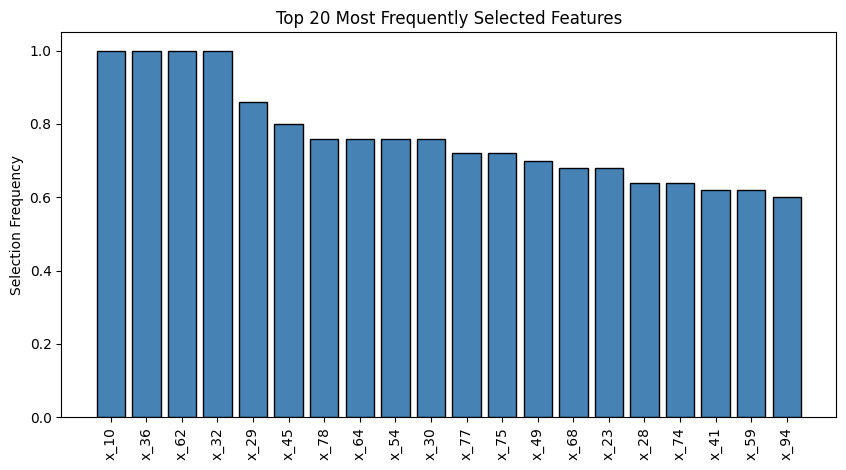

In [9]:
feature_names = X.columns
selection_freq = selection_counts / 50
sorted_idx = np.argsort(selection_freq)[::-1]
top_idx = sorted_idx[:20]

plt.figure(figsize=(10,5))
plt.bar(range(20), selection_freq[top_idx], color='steelblue', edgecolor='black')
plt.xticks(range(20), feature_names[top_idx], rotation=90)
plt.ylabel("Selection Frequency")
plt.title("Top 20 Most Frequently Selected Features")
plt.show()

## 2. Residuals

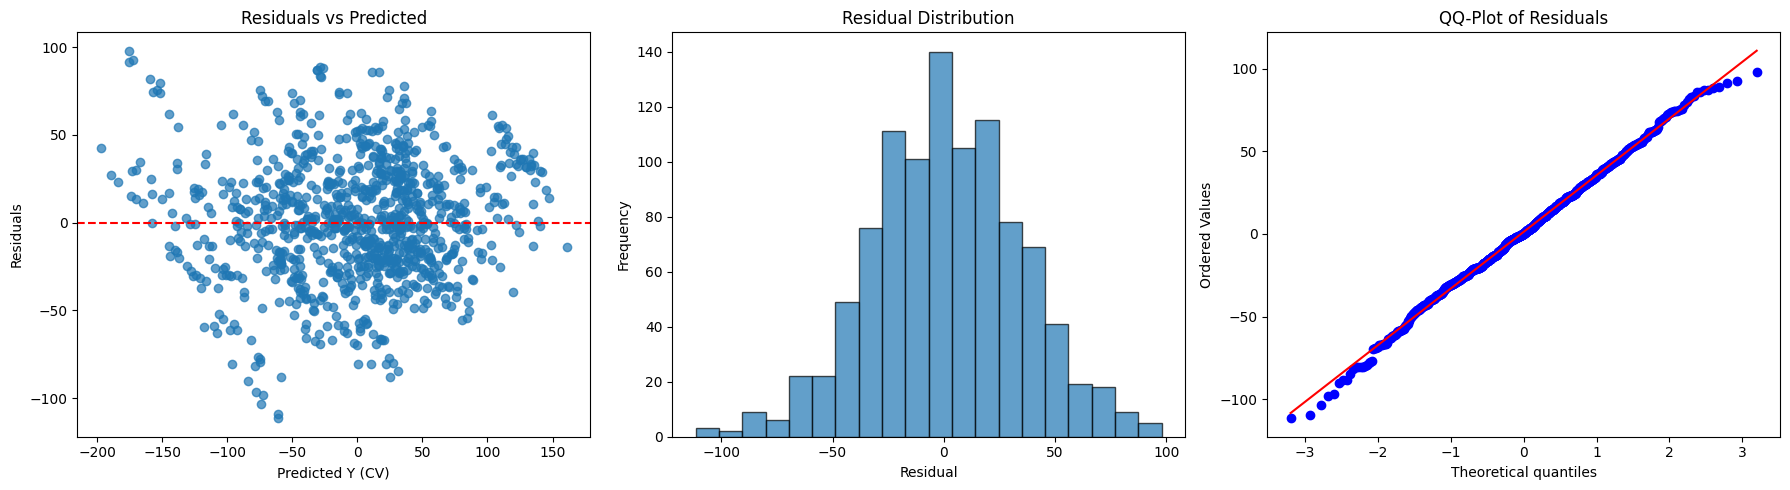

In [6]:
y_cv_true = np.array(y_cv_true)
y_cv_pred = np.array(y_cv_pred)

residuals = y_cv_true - y_cv_pred

fig, axes = plt.subplots(1, 3, figsize=(18,5))  

axes[0].scatter(y_cv_pred, residuals, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted Y (CV)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("QQ-Plot of Residuals")
plt.tight_layout()  
plt.show()

## 3. CV model sleecteion

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)
y_centered, mu = centerData(y_class.values)

# select best alpha
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9,1]  # 1.0 = pure Lasso, 0.0 = Ridge
elastic_final = ElasticNetCV(l1_ratio=l1_ratios,alphas=None,cv=5,fit_intercept=False,max_iter=10000,n_jobs=-1)
elastic_final.fit(X_scaled, y_centered)

final_alpha = elastic_final.alpha_
print(f"Selected alpha: {final_alpha}")

final_ratio = elastic_final.l1_ratio_
print(f"Selected ratio: {final_ratio}")

# see how many coefs are not zero
coef_final = elastic_final.coef_ 
non_zero_count = np.sum(coef_final != 0)
print(f"Number of non-zero coefficients: {non_zero_count}")

c:\Users\Maria\anaconda3\envs\compdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


Selected alpha: 3.7362564912472713
Selected ratio: 1.0
Number of non-zero coefficients: 21
